# Logique and Saha-Belletti: reproducible logical circuit comparison

Both methods use one Grover iteration and an all-bitstrings input preparation. These are logical counts, not routed hardware costs or T-count estimates. The archived paper results remain unchanged.

In [1]:
from pathlib import Path
import os
from IPython.display import display
from logique.benchmarks.runner import load_config, run_benchmarks, new_run_directory
from logique.benchmarks.results import load_results
from logique.visualization.results import plot_results
ROOT = Path(os.environ.get("LOGIQUE_WORKSPACE", Path.cwd()))
OUT = Path(os.environ["LOGIQUE_OUTPUT"]) if "LOGIQUE_OUTPUT" in os.environ else new_run_directory()

In [2]:
config = load_config(ROOT / "configs/coloring_comparison.json", output=str(OUT / "comparison"))
display(config)
run = run_benchmarks(config)
display(load_results(run))

{'kind': 'comparison',
 'inputs': ['/Users/mac/PhD/logique/datasets/graphs/teaching/edge.col'],
 'methods': ['xag', 'sb_original', 'sb_simple', 'sb_minimal', 'sb_balanced'],
 'iterations': 1,
 'seed': 7,
 'validation': 'exhaustive',
 'output': '/Users/mac/PhD/logique/results/20260915T005435Z-ef4bd81e/comparison'}

Grover iterations: 1
Grover iterations: 1
Grover iterations: 1
Grover iterations: 1


,validation,preparation,benchmark,method,seconds,qubits,gates,depth,gate_types,metric_level
0,exhaustive,all bitstrings,edge,xag,0.047317,9,58,26,"{'cx': 16, 'h': 14, 'ccrx': 8, 'ccrx_o0': 8, '...",logical
1,not run,all bitstrings,edge,sb_original,1.234841,8,52,23,"{'x': 17, 'ccx': 12, 'h': 11, 'cx': 8, 'mcx': ...",logical
2,not run,all bitstrings,edge,sb_simple,0.001405,8,47,20,"{'x': 18, 'h': 11, 'cx': 8, 'ccx': 6, 'mcx': 2...",logical
3,not run,all bitstrings,edge,sb_minimal,0.001465,8,68,36,"{'x': 25, 'cx': 16, 'ccx': 13, 'h': 11, 'z': 2...",logical
4,not run,all bitstrings,edge,sb_balanced,0.001114,8,47,20,"{'x': 18, 'h': 11, 'cx': 8, 'ccx': 6, 'mcx': 2...",logical


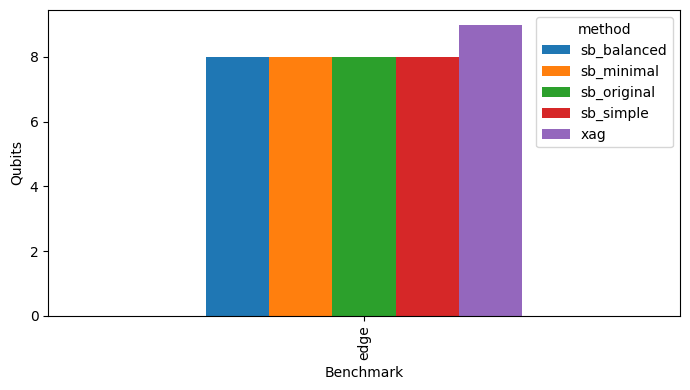

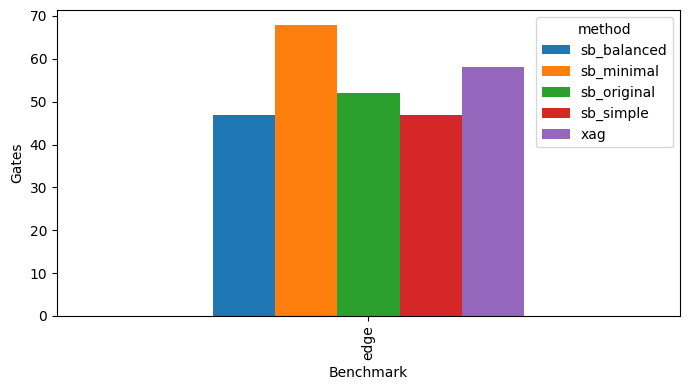

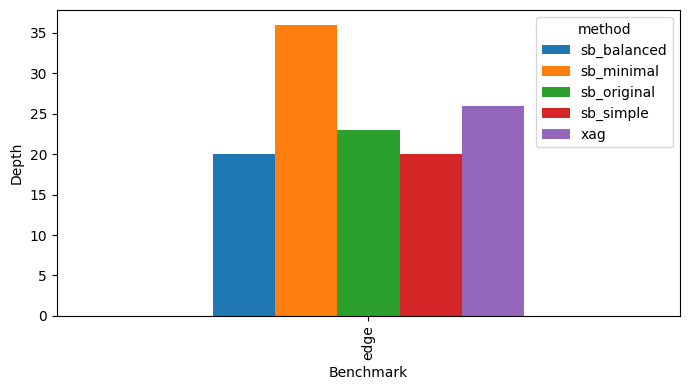

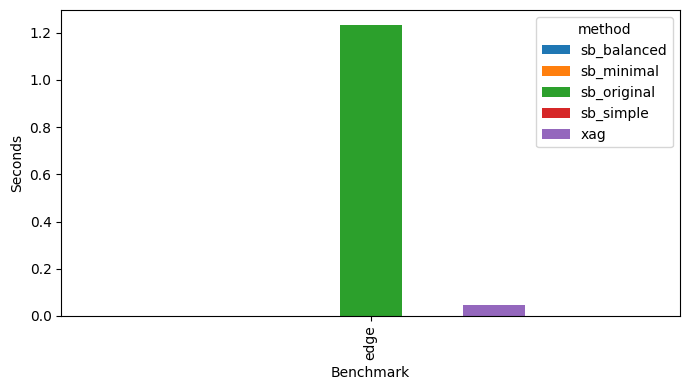

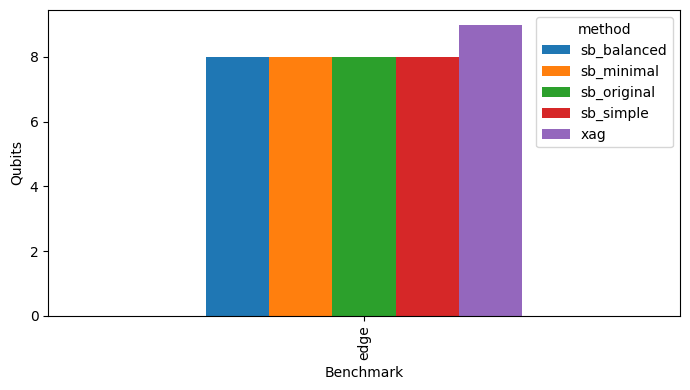

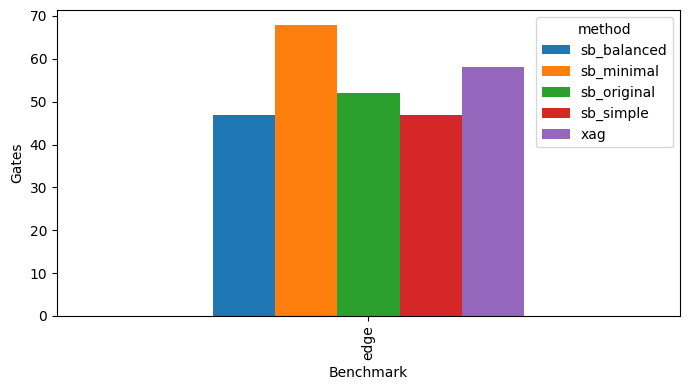

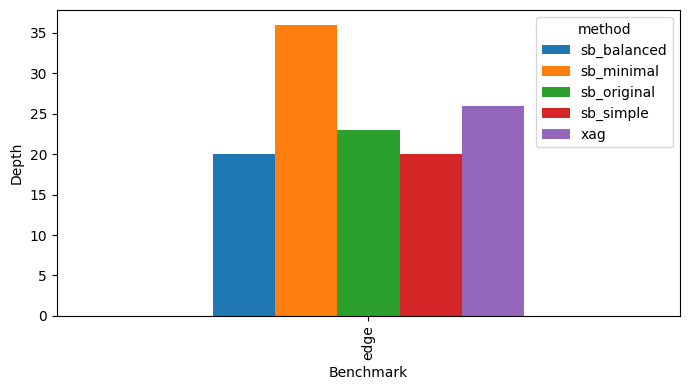

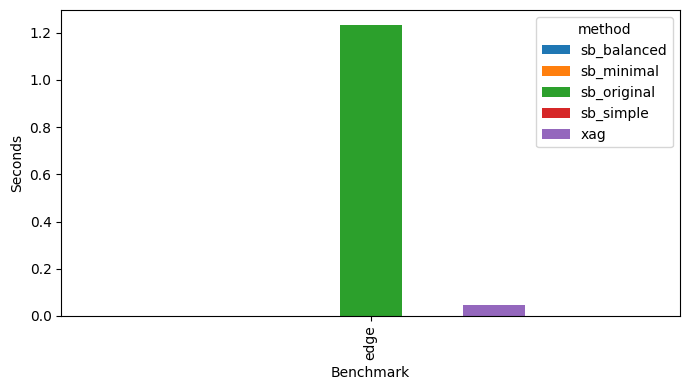

In [3]:
for metric in ("qubits", "gates", "depth", "seconds"):
    display(plot_results(run, metric=metric, output=OUT / f"{metric}.png"))

Saha-Belletti does not honor precolored vertices, so this comparison uses an unprecolored graph. Its adapter preserves the external implementation. Synthesis verification status applies to Logique predicates; it is not a proof of the external backend. No hardware jobs are submitted.